In [1]:
!pip install -q mediapipe opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 7.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


In [2]:
import mediapipe as mp
print(mp.__version__)

0.10.35


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1785040547.353199      75 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785040547.366395      75 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785040547.433117      77 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


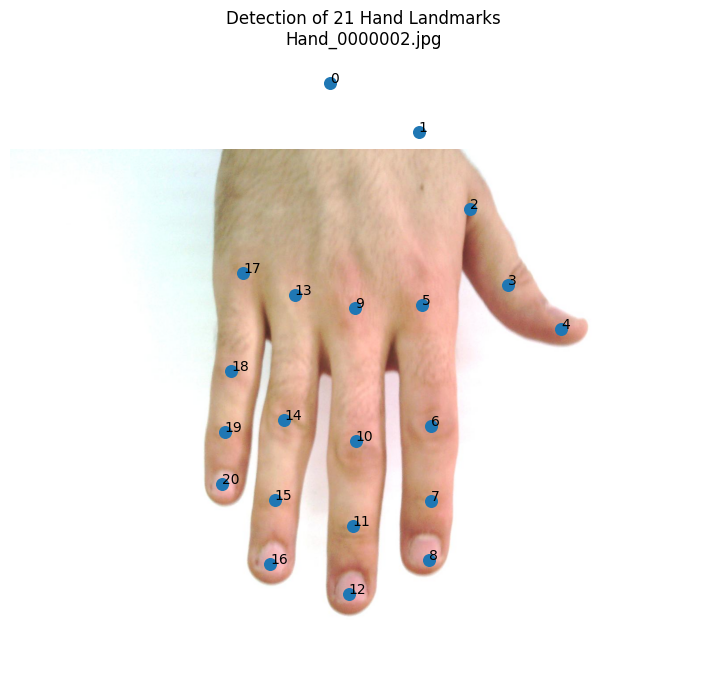

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request

# 1. Check your actual dataset folder structure first
# Run this in a separate cell to confirm paths before running the rest:
# !ls /kaggle/input/
# !find /kaggle/input -iname "*.jpg" | head -5

# 2. Set your paths (adjust based on what !ls showed you)
csv_path = "/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/HandInfo.csv"
hands_path = "/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands"

# 3. Load the CSV into a dataframe
df = pd.read_csv(csv_path)
df = df.rename(columns={"imageName": "filename"})  # matches your code's "filename" reference

# Use it directly, or make a small test subset
test_df = df.iloc[:3000].reset_index(drop=True)  # just first 20 rows to test with

# 4. Download the hand landmarker model (one-time)
model_path = "/kaggle/working/hand_landmarker.task"
if not os.path.exists(model_path):
    url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
    urllib.request.urlretrieve(url, model_path)

# 5. Create the detector
base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=2)
hand_detector = vision.HandLandmarker.create_from_options(options)

# 6. Now your original code
sample_filename = test_df.iloc[0]["filename"]
sample_path = os.path.join(hands_path, sample_filename)

mp_image = mp.Image.create_from_file(sample_path)
result = hand_detector.detect(mp_image)

image_array = mp_image.numpy_view()

plt.figure(figsize=(9, 7))
plt.imshow(image_array)

if result.hand_landmarks:
    landmarks = result.hand_landmarks[0]
    image_height, image_width = image_array.shape[:2]

    x_points = [landmark.x * image_width for landmark in landmarks]
    y_points = [landmark.y * image_height for landmark in landmarks]

    plt.scatter(x_points, y_points, s=70)

    for i, (x, y) in enumerate(zip(x_points, y_points)):
        plt.text(x, y, str(i), fontsize=10)

    plt.title(f"Detection of 21 Hand Landmarks\n{sample_filename}")
else:
    plt.title("No Hand Landmarks Detected")

plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
print(os.path.exists(csv_path))
print(os.path.exists(hands_path))
print(os.listdir(hands_path)[:5])

True
True
['Hand_0009564.jpg', 'Hand_0008693.jpg', 'Hand_0008334.jpg', 'Hand_0006432.jpg', 'Hand_0000951.jpg']


In [5]:
import csv

output_img_dir = "/kaggle/working/annotated_images"
os.makedirs(output_img_dir, exist_ok=True)

coord_path = "/kaggle/working/landmark_coords.csv"

with open(coord_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["filename", "landmark_id", "x", "y", "z"])

    for idx, row in test_df.iterrows():
        filename = row["filename"]
        img_path = os.path.join(hands_path, filename)

        mp_image = mp.Image.create_from_file(img_path)
        result = hand_detector.detect(mp_image)

        image_array = mp_image.numpy_view()

        if not result.hand_landmarks:
            print(f"No hand detected: {filename}")
            continue

        landmarks = result.hand_landmarks[0]
        image_height, image_width = image_array.shape[:2]

        x_points = [lm.x * image_width for lm in landmarks]
        y_points = [lm.y * image_height for lm in landmarks]

        # Save annotated image
        plt.figure(figsize=(9, 7))
        plt.imshow(image_array)
        plt.scatter(x_points, y_points, s=70)
        for i, (x, y) in enumerate(zip(x_points, y_points)):
            plt.text(x, y, str(i), fontsize=10)
        plt.title(f"Detection of 21 Hand Landmarks\n{filename}")
        plt.axis("off")
        plt.tight_layout()
        plt.savefig(os.path.join(output_img_dir, f"{filename}_landmarks.png"))
        plt.close()  # important: prevents memory buildup over many images

        # Export raw (x, y, z) coordinates — normalized, not pixel-scaled
        for i, lm in enumerate(landmarks):
            writer.writerow([filename, i, lm.x, lm.y, lm.z])

        print(f"Processed {idx+1}/{len(test_df)}: {filename}")

print("Done. Annotated images in:", output_img_dir)
print("Coordinates saved to:", coord_path)

Processed 1/3000: Hand_0000002.jpg
Processed 2/3000: Hand_0000003.jpg
Processed 3/3000: Hand_0000004.jpg
Processed 4/3000: Hand_0000005.jpg
Processed 5/3000: Hand_0000006.jpg
Processed 6/3000: Hand_0000007.jpg
Processed 7/3000: Hand_0000008.jpg
Processed 8/3000: Hand_0000009.jpg
Processed 9/3000: Hand_0000010.jpg
Processed 10/3000: Hand_0000011.jpg
Processed 11/3000: Hand_0000012.jpg
Processed 12/3000: Hand_0000013.jpg
Processed 13/3000: Hand_0000014.jpg
Processed 14/3000: Hand_0000015.jpg
Processed 15/3000: Hand_0000016.jpg
Processed 16/3000: Hand_0000020.jpg
Processed 17/3000: Hand_0000021.jpg
Processed 18/3000: Hand_0000022.jpg
Processed 19/3000: Hand_0000023.jpg
Processed 20/3000: Hand_0000024.jpg
Processed 21/3000: Hand_0000025.jpg
Processed 22/3000: Hand_0000026.jpg
Processed 23/3000: Hand_0000027.jpg
Processed 24/3000: Hand_0000028.jpg
Processed 25/3000: Hand_0000029.jpg
Processed 26/3000: Hand_0000030.jpg
Processed 27/3000: Hand_0000031.jpg
Processed 28/3000: Hand_0000032.jpg
P

In [6]:
#Feature Engineering
import pandas as pd
import numpy as np

# Load landmark coordinates
df = pd.read_csv("/kaggle/working/landmark_coords.csv")

# Euclidean distance function
def distance(p1, p2):
    return np.sqrt(
        (p1["x"] - p2["x"])**2 +
        (p1["y"] - p2["y"])**2 +
        (p1["z"] - p2["z"])**2
    )

features = []

for filename, group in df.groupby("filename"):

    group = group.sort_values("landmark_id").reset_index(drop=True)

    if len(group) != 21:
        continue

    # Palm measurements
    palm_width = distance(group.iloc[5], group.iloc[17])
    palm_height = distance(group.iloc[0], group.iloc[9])

    # Finger lengths
    thumb_length = (
        distance(group.iloc[1], group.iloc[2]) +
        distance(group.iloc[2], group.iloc[3]) +
        distance(group.iloc[3], group.iloc[4])
    )

    index_length = (
        distance(group.iloc[5], group.iloc[6]) +
        distance(group.iloc[6], group.iloc[7]) +
        distance(group.iloc[7], group.iloc[8])
    )

    middle_length = (
        distance(group.iloc[9], group.iloc[10]) +
        distance(group.iloc[10], group.iloc[11]) +
        distance(group.iloc[11], group.iloc[12])
    )

    ring_length = (
        distance(group.iloc[13], group.iloc[14]) +
        distance(group.iloc[14], group.iloc[15]) +
        distance(group.iloc[15], group.iloc[16])
    )

    little_length = (
        distance(group.iloc[17], group.iloc[18]) +
        distance(group.iloc[18], group.iloc[19]) +
        distance(group.iloc[19], group.iloc[20])
    )

    aspect_ratio = palm_height / palm_width if palm_width != 0 else 0

    features.append([
        filename,
        palm_width,
        palm_height,
        thumb_length,
        index_length,
        middle_length,
        ring_length,
        little_length,
        aspect_ratio
    ])

# Create feature dataframe
feature_df = pd.DataFrame(features, columns=[
    "filename",
    "palm_width",
    "palm_height",
    "thumb_length",
    "index_length",
    "middle_length",
    "ring_length",
    "little_length",
    "aspect_ratio"
])

# Save features
feature_df.to_csv("/kaggle/working/palm_features.csv", index=False)

print(feature_df.head())
print("Total hands processed:", len(feature_df))
print("Saved as: /kaggle/working/palm_features.csv")

           filename  palm_width  palm_height  thumb_length  index_length  \
0  Hand_0000002.jpg    0.260342     0.438580      0.440385      0.490586   
1  Hand_0000003.jpg    0.263889     0.434762      0.437788      0.484436   
2  Hand_0000004.jpg    0.252337     0.409462      0.434339      0.482815   
3  Hand_0000005.jpg    0.251028     0.410806      0.458526      0.494063   
4  Hand_0000006.jpg    0.258284     0.417347      0.444654      0.475146   

   middle_length  ring_length  little_length  aspect_ratio  
0       0.546106     0.515422       0.403868      1.684625  
1       0.535702     0.506209       0.403088      1.647516  
2       0.544500     0.507708       0.401512      1.622681  
3       0.553957     0.514012       0.405956      1.636494  
4       0.534538     0.504858       0.394475      1.615841  
Total hands processed: 2864
Saved as: /kaggle/working/palm_features.csv


In [7]:
#feature eda
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/working/palm_features.csv")

print(df.head())
print(df.shape)

           filename  palm_width  palm_height  thumb_length  index_length  \
0  Hand_0000002.jpg    0.260342     0.438580      0.440385      0.490586   
1  Hand_0000003.jpg    0.263889     0.434762      0.437788      0.484436   
2  Hand_0000004.jpg    0.252337     0.409462      0.434339      0.482815   
3  Hand_0000005.jpg    0.251028     0.410806      0.458526      0.494063   
4  Hand_0000006.jpg    0.258284     0.417347      0.444654      0.475146   

   middle_length  ring_length  little_length  aspect_ratio  
0       0.546106     0.515422       0.403868      1.684625  
1       0.535702     0.506209       0.403088      1.647516  
2       0.544500     0.507708       0.401512      1.622681  
3       0.553957     0.514012       0.405956      1.636494  
4       0.534538     0.504858       0.394475      1.615841  
(2864, 9)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2864 entries, 0 to 2863
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   filename       2864 non-null   object 
 1   palm_width     2864 non-null   float64
 2   palm_height    2864 non-null   float64
 3   thumb_length   2864 non-null   float64
 4   index_length   2864 non-null   float64
 5   middle_length  2864 non-null   float64
 6   ring_length    2864 non-null   float64
 7   little_length  2864 non-null   float64
 8   aspect_ratio   2864 non-null   float64
dtypes: float64(8), object(1)
memory usage: 201.5+ KB


In [9]:
print(df.isnull().sum())

filename         0
palm_width       0
palm_height      0
thumb_length     0
index_length     0
middle_length    0
ring_length      0
little_length    0
aspect_ratio     0
dtype: int64


In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


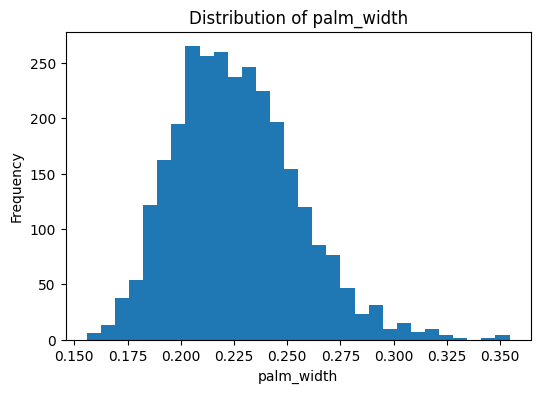

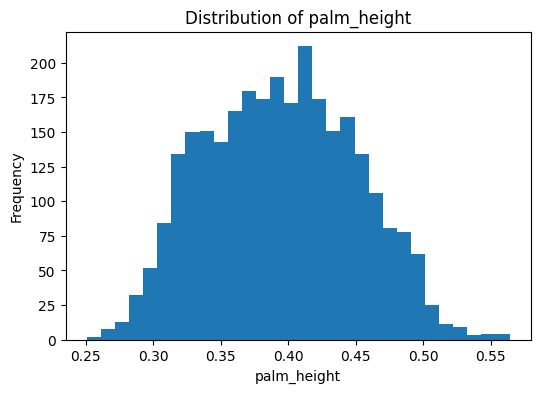

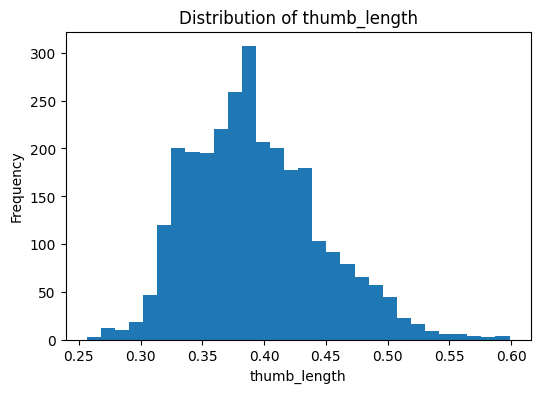

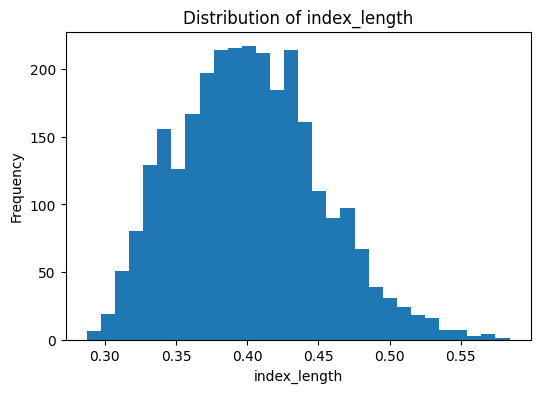

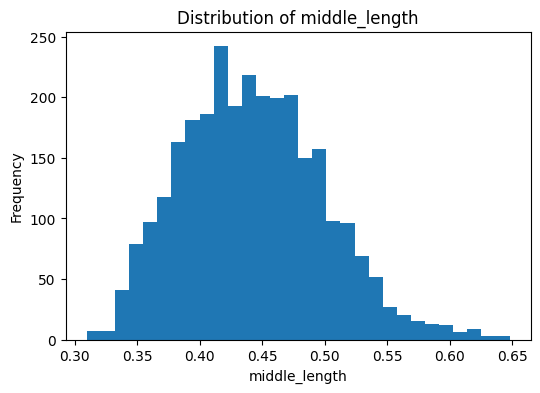

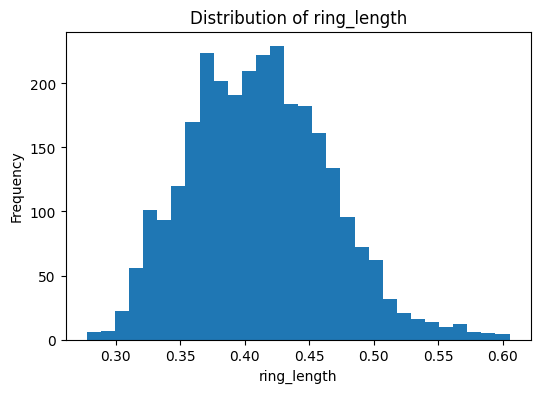

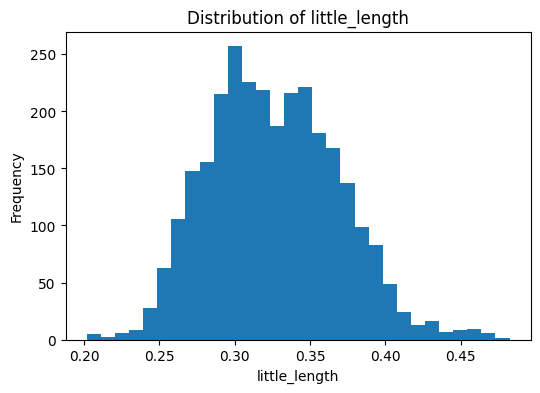

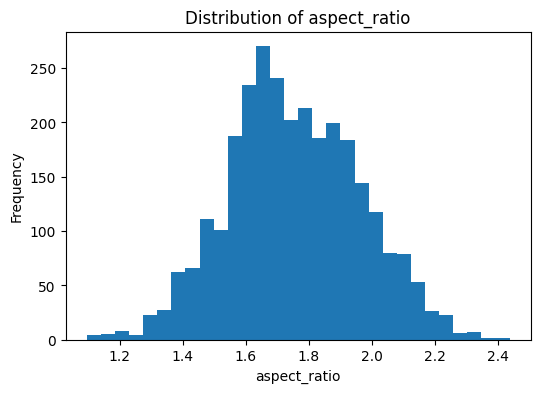

In [11]:
#Distribution of Numerical Features
num_cols = df.columns[1:]

for col in num_cols:

    plt.figure(figsize=(6,4))

    plt.hist(df[col], bins=30)

    plt.title(f"Distribution of {col}")

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()

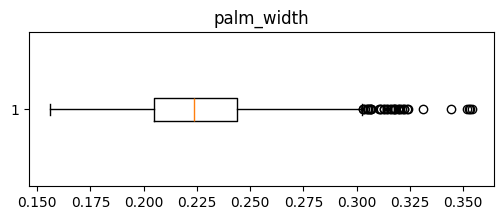

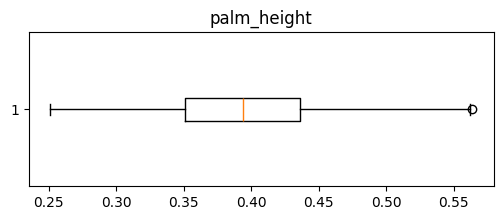

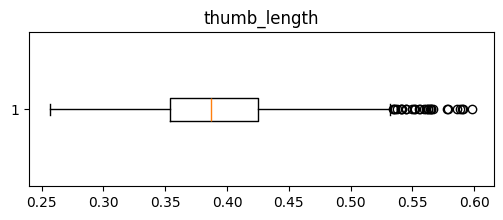

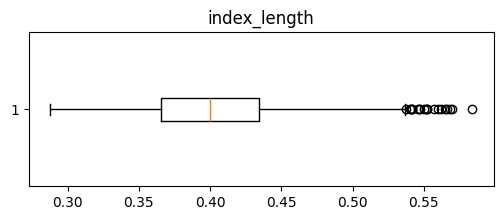

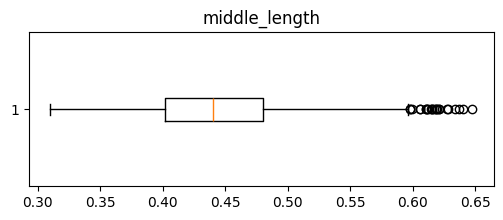

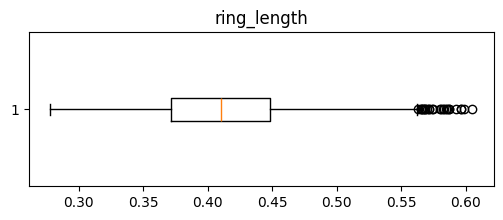

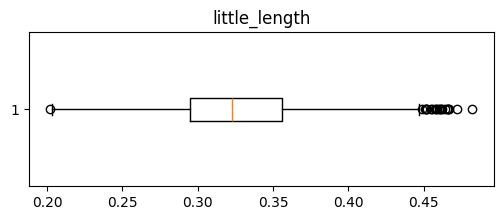

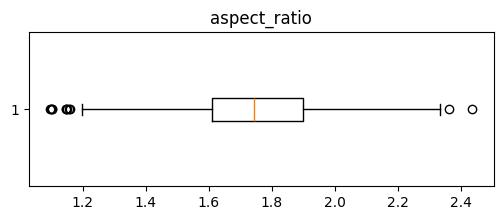

In [12]:
#Boxplot
for col in num_cols:

    plt.figure(figsize=(6,2))

    plt.boxplot(df[col], vert=False)

    plt.title(col)

    plt.show()

In [13]:
#correlation matrix
corr = df[num_cols].corr()

corr

,palm_width,palm_height,thumb_length,index_length,middle_length,ring_length,little_length,aspect_ratio
palm_width,1.000000,0.618437,0.648319,0.718176,0.651561,0.641037,0.615274,-0.331529
palm_height,0.618437,1.000000,0.809546,0.330428,0.235872,0.222928,0.289857,0.529160
thumb_length,0.648319,0.809546,1.000000,0.503807,0.400153,0.370405,0.410919,0.269131
index_length,0.718176,0.330428,0.503807,1.000000,0.966834,0.946793,0.891719,-0.381091
middle_length,0.651561,0.235872,0.400153,0.966834,1.000000,0.984324,0.921932,-0.422893
ring_length,0.641037,0.222928,0.370405,0.946793,0.984324,1.000000,0.941542,-0.427855
little_length,0.615274,0.289857,0.410919,0.891719,0.921932,0.941542,1.000000,-0.321122
aspect_ratio,-0.331529,0.529160,0.269131,-0.381091,-0.422893,-0.427855,-0.321122,1.000000


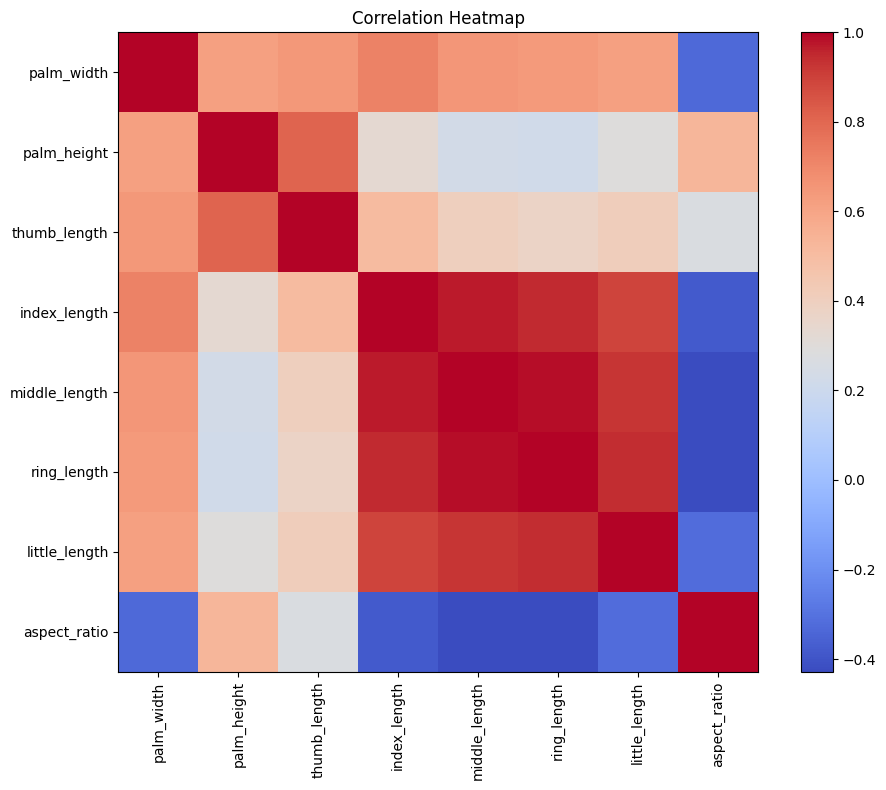

In [14]:
#heatmap
plt.figure(figsize=(10,8))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

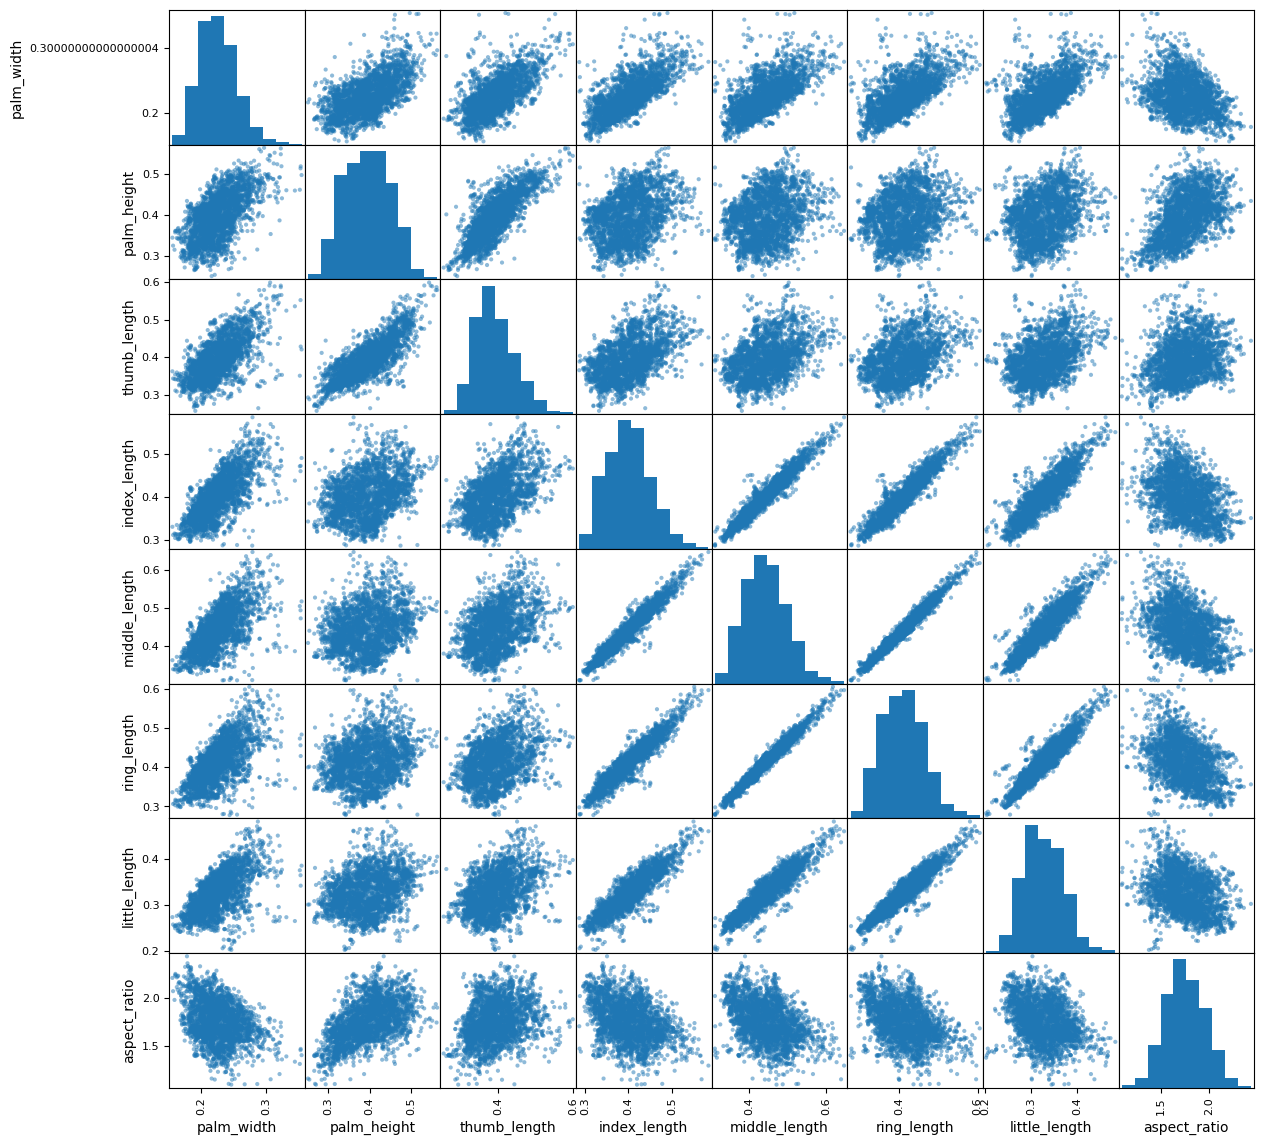

In [15]:
#pairwise relationships
pd.plotting.scatter_matrix(
    df[num_cols],
    figsize=(14,14),
    diagonal="hist"
)

plt.show()

In [16]:
df.to_csv("/kaggle/working/palm_features_clean.csv", index=False)

print("Saved Successfully")

Saved Successfully


EDA Summary
The dataset contains 2,864 palm samples with 9 columns.
No missing values were found.
No duplicate records were found.
Palm width, palm height, and finger lengths show continuous numerical distributions.
Correlation analysis helps identify relationships among engineered palm features.
The dataset is clean and suitable for machine learning model development.
